# Main Figures 11–13

Persistent-anticyclone evolution, propagation, and overlap duration. Each generated figure is displayed immediately after its plotting cell.


In [1]:
from __future__ import annotations
import hashlib, importlib.metadata, io, json, math, os, re, shutil, sys, zipfile
from contextlib import redirect_stderr, redirect_stdout
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/james-mpl-cache")
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image as NotebookImage, SVG, display
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy import ndimage
from scipy.integrate import cumulative_trapezoid, trapezoid
from scipy.interpolate import interp1d

try:
    import cartopy.crs as ccrs
    HAVE_CARTOPY = True
except ImportError:
    HAVE_CARTOPY = False
try:
    import wavebreaking as wb
    HAVE_WAVEBREAKING = True
except ImportError:
    HAVE_WAVEBREAKING = False
try:
    from contrack import contrack as ConTrack
    HAVE_CONTRACK = True
except ImportError:
    HAVE_CONTRACK = False

def find_repo_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "ready_version").is_dir() and (candidate / "derived_data").is_dir():
            return candidate
    raise FileNotFoundError("Run from the repository or one of its subdirectories")

ROOT = find_repo_root()
RAW_DIR = ROOT
DERIVED_DIR = ROOT / "derived_data"
PUBLICATION_DIR = ROOT / "publication_notebooks"
FIGURE_DIR = PUBLICATION_DIR / "outputs"
TABLE_DIR = PUBLICATION_DIR / "outputs"
SI_DIR = ROOT / "paper_revision" / "supplemental_analysis"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RUN_HEAVY_PROCESSING = False
USE_PRECOMPUTED_DERIVED_DATA = True
SAVE_FIGURES = True
SHOW_FIGURES = False
REBUILD_FIGURES = os.environ.get(
    "PUBLICATION_REBUILD_FIGURES",
    os.environ.get("PUBLICATION_FULL_REBUILD", "1"),
) == "1"
FULL_REBUILD = REBUILD_FIGURES
EARTH_RADIUS_M = 6_371_229.0
EARTH_OMEGA = 7.2921e-5
GRAVITY = 9.80616
RD = 287.05
CP = 1004.0
KAPPA = RD / CP
mpl.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 9})

def show_docx_media(docx_relative_path, members):
    members = [members] if isinstance(members, str) else list(members)
    with zipfile.ZipFile(ROOT / docx_relative_path) as archive:
        for member in members:
            payload = archive.read(member)
            display(SVG(data=payload.decode("utf-8")) if member.lower().endswith(".svg") else NotebookImage(data=payload))

def show_files(paths):
    paths = [paths] if isinstance(paths, str) else list(paths)
    for relative_path in paths:
        path = ROOT / relative_path
        if path.exists() and path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
            display(NotebookImage(filename=str(path)))

# Optional environment diagnostics are intentionally disabled in the public notebooks.
# print(f"Repository root: {ROOT.relative_to(ROOT)}")
# print(f"Rebuild figures: {REBUILD_FIGURES}")
# print(f"Cartopy={HAVE_CARTOPY}, WaveBreaking={HAVE_WAVEBREAKING}, ConTrack={HAVE_CONTRACK}")


In [2]:
B_VALUES=(1.0,1.5,2.0); N_VALUES=(1,3,6); S_VALUES=(-10,-5,0,5,10)
def case_stem(b,n,s):
    bt='15' if np.isclose(b,1.5) else str(int(b))
    return f'BCwave_b{bt}n{n}' + ('' if s==0 else f's{s}')
def experiment_manifest():
    rows=[]
    for b in B_VALUES:
      for n in N_VALUES:
       for s in S_VALUES:
        stem=case_stem(b,n,s)
        rows.append({'case':stem.replace('BCwave_',''),'b':b,'n':n,'s_deg':s,
          'raw_file':f'{stem}.nc',
          'coarse_file':f'derived_data/coarse5avg/{stem}.nc',
          'pv_file':f'derived_data/pv_isentropic/{stem}.nc'})
    return pd.DataFrame(rows)
TABLE1=experiment_manifest(); assert len(TABLE1)==45
TABLE1.to_csv(TABLE_DIR/'Table1_experiment_manifest.csv',index=False)
# Optional manifest preview is disabled to keep notebook output figure-only.
# display(TABLE1)


In [3]:
def open_case(case, coarse=False, chunks=None):
    stem=case if str(case).startswith('BCwave_') else f'BCwave_{case}'
    path=(DERIVED_DIR/'coarse5avg' if coarse else RAW_DIR)/f'{stem}.nc'
    if not path.exists(): raise FileNotFoundError(path)
    return xr.open_dataset(path,decode_times=False,chunks=chunks)
def standardize_latlon(obj):
    rename={}
    if 'grid_yt' in obj.dims or 'grid_yt' in obj.coords: rename['grid_yt']='latitude'
    if 'grid_xt' in obj.dims or 'grid_xt' in obj.coords: rename['grid_xt']='longitude'
    return obj.rename(rename)
def daily_mean(ds): return ds.coarsen(time=24,boundary='trim').mean()
def save_figure(fig,name):
    path=FIGURE_DIR/name
    if SAVE_FIGURES: fig.savefig(path,bbox_inches='tight',facecolor='white')
    if SHOW_FIGURES: plt.show()
    else: plt.close(fig)
    return path
def nearest_level(levels,target): return int(np.nanargmin(np.abs(np.asarray(levels)-target)))
def grid_cell_area(latitude,dlat_deg=1.,dlon_deg=1.):
    lat=np.deg2rad(np.asarray(latitude)); dlat=np.deg2rad(dlat_deg); dlon=np.deg2rad(dlon_deg)
    return EARTH_RADIUS_M**2*dlon*(np.sin(lat+dlat/2)-np.sin(lat-dlat/2))
def haversine_m(lat1,lon1,lat2,lon2):
    lat1,lon1,lat2,lon2=map(np.deg2rad,(lat1,lon1,lat2,lon2)); dlat=lat2-lat1; dlon=(lon2-lon1+np.pi)%(2*np.pi)-np.pi
    h=np.sin(dlat/2)**2+np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*EARTH_RADIUS_M*np.arcsin(np.minimum(1,np.sqrt(h)))
def relative_vorticity(u,v,latitude,longitude):
    lat=np.deg2rad(np.asarray(latitude,float)); lon=np.deg2rad(np.asarray(longitude,float)); coslat=np.cos(lat)
    dvdl=np.gradient(np.asarray(v,float),lon,axis=-1,edge_order=2)
    ducos=np.gradient(np.asarray(u,float)*coslat[...,None],lat,axis=-2,edge_order=2)
    with np.errstate(divide='ignore',invalid='ignore'): return (dvdl-ducos)/(EARTH_RADIUS_M*coslat[...,None])
def theta(T,p_hpa): return np.asarray(T)*(1000/np.asarray(p_hpa))**KAPPA
def pressure_pv(u,v,T,p_hpa,latitude,longitude):
    p=np.asarray(p_hpa,float)*100; zeta=relative_vorticity(u,v,latitude,longitude)
    coriolis=(2*EARTH_OMEGA*np.sin(np.deg2rad(latitude)))[None,:,None]
    dtheta_dp=np.gradient(theta(T,np.asarray(p_hpa)[:,None,None]),p,axis=0,edge_order=2)
    return -GRAVITY*(zeta+coriolis)*dtheta_dp*1e6
def area_weights(latitude):
    w=np.cos(np.deg2rad(latitude)); return w/w.sum()


## Figure 11


In [4]:
def plot_figure11():
    import xarray as xr
    import cartopy.crs as ccrs
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    from matplotlib.ticker import FuncFormatter
    from matplotlib.path import Path
    import numpy as np
    ds = xr.open_dataset(RAW_DIR / 'BCwave_b2n1s10.nc', decode_times=False)
    times = [i * 24 for i in range(7, 13)]
    letters = [chr(ord('a') + k) for k in range(len(times))]
    levels_omg = [-0.24, -0.2, -0.16, -0.08, -0.04, 0.04, 0.08, 0.16, 0.2, 0.24]
    levels_p = np.arange(800, 1060, 10) * 100
    levels_p = levels_p[levels_p != 1000 * 100]
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12), dpi=300, subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=0)})
    axes = axes.flatten()

    def make_lon_formatter(col):
        """
        col = 0: left column → only 90°W
        col = 1: middle column → no 90°W or 90°E
        col = 2: right column → only 90°E
        """

        def fmt(x, pos):
            if x == -90 and col == 0:
                return '90°W'
            if x == 0:
                return '0°'
            if x == 90 and col == 2:
                return '90°E'
            if x == 180:
                return '180°'
            return ''
        return fmt
    for idx, (ax, t_idx, letter, day) in enumerate(zip(axes, times, letters, range(7, 13))):
        col = idx % 3
        press = ds['PRESsfc'].isel(time=t_idx)
        omg500 = ds['omg_plev'].sel(plev=500).isel(time=t_idx)
        omg500 = omg500.where(np.abs(omg500) >= 0.08, 0)
        ax.set_extent([-180, 180, 30, 90], ccrs.PlateCarree())
        theta = np.linspace(0, 2 * np.pi, 400)
        verts = np.column_stack([0.5 + 0.5 * np.cos(theta), 0.5 + 0.5 * np.sin(theta)])
        codes = np.full(len(theta), Path.LINETO, dtype=Path.code_type)
        codes[0], codes[-1] = (Path.MOVETO, Path.CLOSEPOLY)
        ax.set_boundary(Path(verts, codes), transform=ax.transAxes)
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linestyle='--', linewidth=0.5, color='gray', x_inline=False, y_inline=False, rotate_labels=False)
        lon_ticks = [-150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150, 180]
        gl.xlocator = mticker.FixedLocator(lon_ticks)
        gl.xformatter = FuncFormatter(make_lon_formatter(col))
        gl.xlabels_top = True
        gl.xlabels_bottom = False
        gl.ylabels_left = False
        gl.ylabels_right = False
        gl.xlabel_style = {'size': 12}
        cf = ax.contourf(omg500['grid_xt'], omg500['grid_yt'], omg500, transform=ccrs.PlateCarree(), cmap='RdBu_r', levels=levels_omg, extend='both', alpha=0.6)
        cs = ax.contour(press['grid_xt'], press['grid_yt'], press, transform=ccrs.PlateCarree(), levels=levels_p, colors='black', linewidths=1.0, linestyles='solid')
        if letter in ['d', 'f']:
            lon1, lon2 = (100, 250)
            lat1, lat2 = (30, 80)
            rect_lons = [lon1, lon2, lon2, lon1, lon1]
            rect_lats = [lat1, lat1, lat2, lat2, lat1]
            ax.plot(rect_lons, rect_lats, transform=ccrs.PlateCarree(), color='black', linewidth=3.0, zorder=10)
        ax.set_title(f'({letter}) Day {day}', fontsize=24, loc='center')
    "\ncbar = fig.colorbar(\n    cf, ax=axes.tolist(),\n    orientation='horizontal',\n    pad=0.05, fraction=0.05\n)\ncbar.set_label('500 hPa Vertical Velocity (Pa s⁻¹)', size=12)\n"
    plt.tight_layout()
    output = save_figure(fig, 'Figure11_persistent_anticyclone.png')
    return output


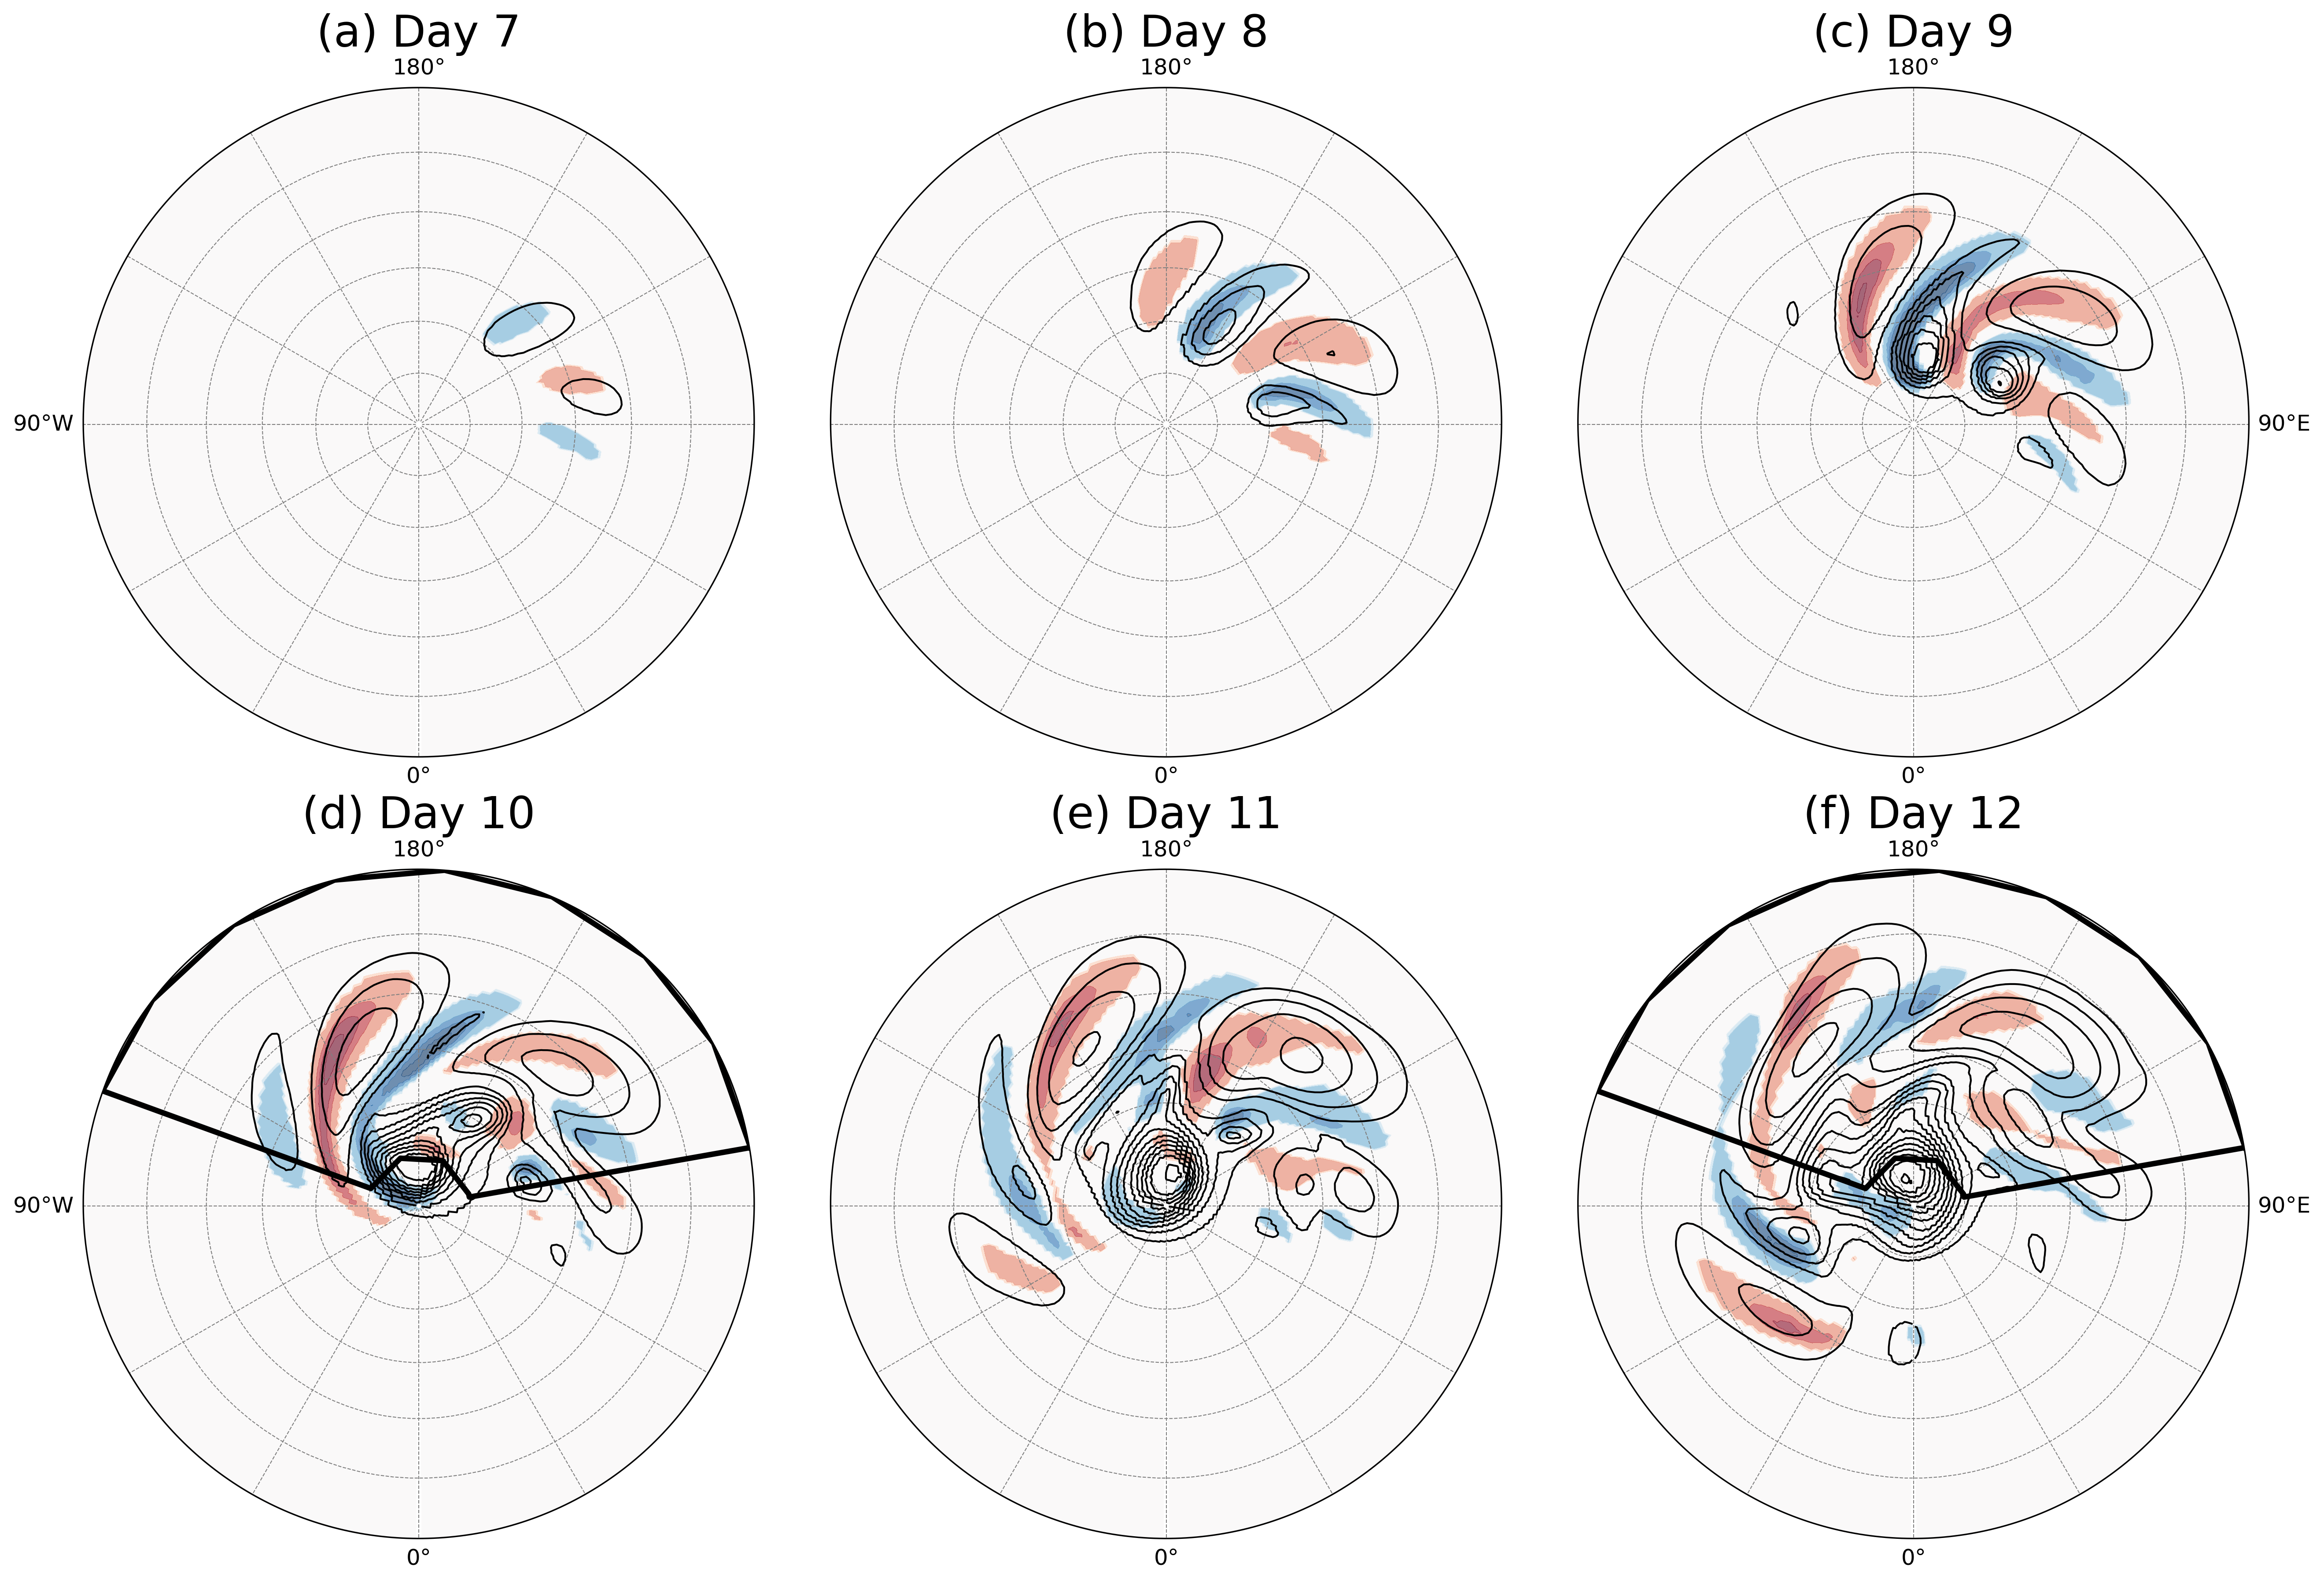

In [5]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            plot_figure11()
finally:
    sys.argv = _original_argv
show_files(['publication_notebooks/outputs/Figure11_persistent_anticyclone.png'])


## Figure 12


In [6]:
# Consolidated from paper_revision/figure_updates/rebuild_figures_8_12.py
REPO_ROOT = ROOT
__file__ = str(ROOT / 'paper_revision/figure_updates/rebuild_figures_8_12.py')

"""Rebuild corrected manuscript Figures 8 and 12 from their notebook sources."""
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.font_manager import findfont
from PIL import Image, ImageDraw, ImageFont
ROOT = Path(__file__).resolve().parents[2]
OUTDIR = ROOT / 'current_version' / 'updated_figures'
MANUSCRIPT = ROOT / 'current_version' / 'AGU_Manuscript_FV3_Mingfei.docx'

def rebuild_figure8() -> Path:
    """Keep the original Figure 8 fields and curves, correcting only right-panel labels."""
    OUTDIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(MANUSCRIPT) as archive:
        original = Image.open(archive.open('word/media/image13.png')).convert('RGB')
    draw = ImageDraw.Draw(original)
    font_path = findfont('DejaVu Sans')
    legend_font = ImageFont.truetype(font_path, 27)
    xlabel_font = ImageFont.truetype(font_path, 31)
    draw.rectangle((1535, 487, 1990, 592), fill='white')
    for y, text in ((493, 'n=1 (broad jet)'), (531, 'n=3 (moderate)'), (569, 'n=6 (narrow jet)')):
        draw.text((1552, y), text, fill='black', font=legend_font)
    draw.rectangle((1535, 923, 1970, 1060), fill='white')
    for y, text in ((929, 'b=1 (smaller b)'), (967, 'b=1.5 (intermediate b)'), (1005, 'b=2 (larger b)')):
        draw.text((1552, y), text, fill='black', font=legend_font)
    draw.rectangle((1300, 1345, 2498, 1458), fill='white')
    xlabel = 'Relative time since pressure connection (hours)'
    box = draw.textbbox((0, 0), xlabel, font=xlabel_font)
    text_width = box[2] - box[0]
    draw.text((1930 - text_width / 2, 1398), xlabel, fill='black', font=xlabel_font)
    output = OUTDIR / 'Figure8_corrected.png'
    original.save(output, dpi=(300, 300))
    return output

def rebuild_figure12() -> Path:
    """Reproduce exploratory/check.ipynb Figure 12 with b=15 displayed as b=1.5."""
    OUTDIR.mkdir(parents=True, exist_ok=True)
    boundaries = [990, 992, 994, 996, 998, 1002, 1004, 1006, 1008, 1010]
    base_cmap = plt.get_cmap('coolwarm', len(boundaries) - 1)
    colors = base_cmap(np.arange(base_cmap.N))
    colors[np.searchsorted(boundaries, 1000) - 1] = [1, 1, 1, 1]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=True)
    letters = [chr(ord('a') + index) for index in range(9)]
    fig, axes = plt.subplots(3, 3, figsize=(13.38, 9.63), sharex=True, sharey=True)
    image = None
    for column, n_value in enumerate([6, 3, 1]):
        for row, b_file_value in enumerate([2, 15, 1]):
            axis = axes[row, column]
            path = ROOT / f'BCwave_b{b_file_value}n{n_value}s10.nc'
            with xr.open_dataset(path, decode_times=False) as dataset:
                pressure = dataset['PRESsfc'].sel(grid_yt=slice(0, 50))
                latitude = pressure['grid_yt']
                weights = np.cos(np.deg2rad(latitude))
                weights /= weights.sum(dim='grid_yt')
                pressure_average = ((pressure * weights).sum(dim='grid_yt') / 100.0).isel(time=slice(200, None)).load()
                time = dataset['time'].values
                longitude = dataset['grid_xt'].values
            image = axis.imshow(pressure_average.values, aspect='auto', extent=[longitude.min(), longitude.max(), time[200], time[-1]], cmap=cmap, norm=norm, origin='lower', interpolation='none')
            panel_index = row * 3 + column
            b_display = 1.5 if b_file_value == 15 else b_file_value
            axis.set_title(f'({letters[panel_index]})  b={b_display:g}, n={n_value}', fontsize=16, fontweight='bold')
            axis.set_xticks([0, 90, 180, 270, 360])
            axis.set_yticks([200, 250, 300, 350])
            axis.tick_params(axis='both', labelsize=14)
            axis.grid(True, alpha=0.55)
    fig.supxlabel('Longitude', fontsize=17, y=0.035)
    fig.supylabel('Time', fontsize=17, x=0.035)
    colorbar_axis = fig.add_axes([0.92, 0.16, 0.022, 0.68])
    colorbar = fig.colorbar(image, cax=colorbar_axis, boundaries=boundaries, ticks=boundaries, spacing='proportional')
    colorbar.set_label('Average PRESsfc (hPa)', fontsize=16)
    colorbar.ax.tick_params(labelsize=14)
    fig.tight_layout(rect=[0.055, 0.06, 0.9, 0.98])
    output = OUTDIR / 'Figure12_corrected.png'
    fig.savefig(output, dpi=240, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    return output

def main() -> None:
    print(rebuild_figure8())
    print(rebuild_figure12())

def plot_figure12():
    source = rebuild_figure12()
    output = FIGURE_DIR / 'Figure12_high_pressure_hovmoller.png'
    shutil.copy2(source, output)
    return output


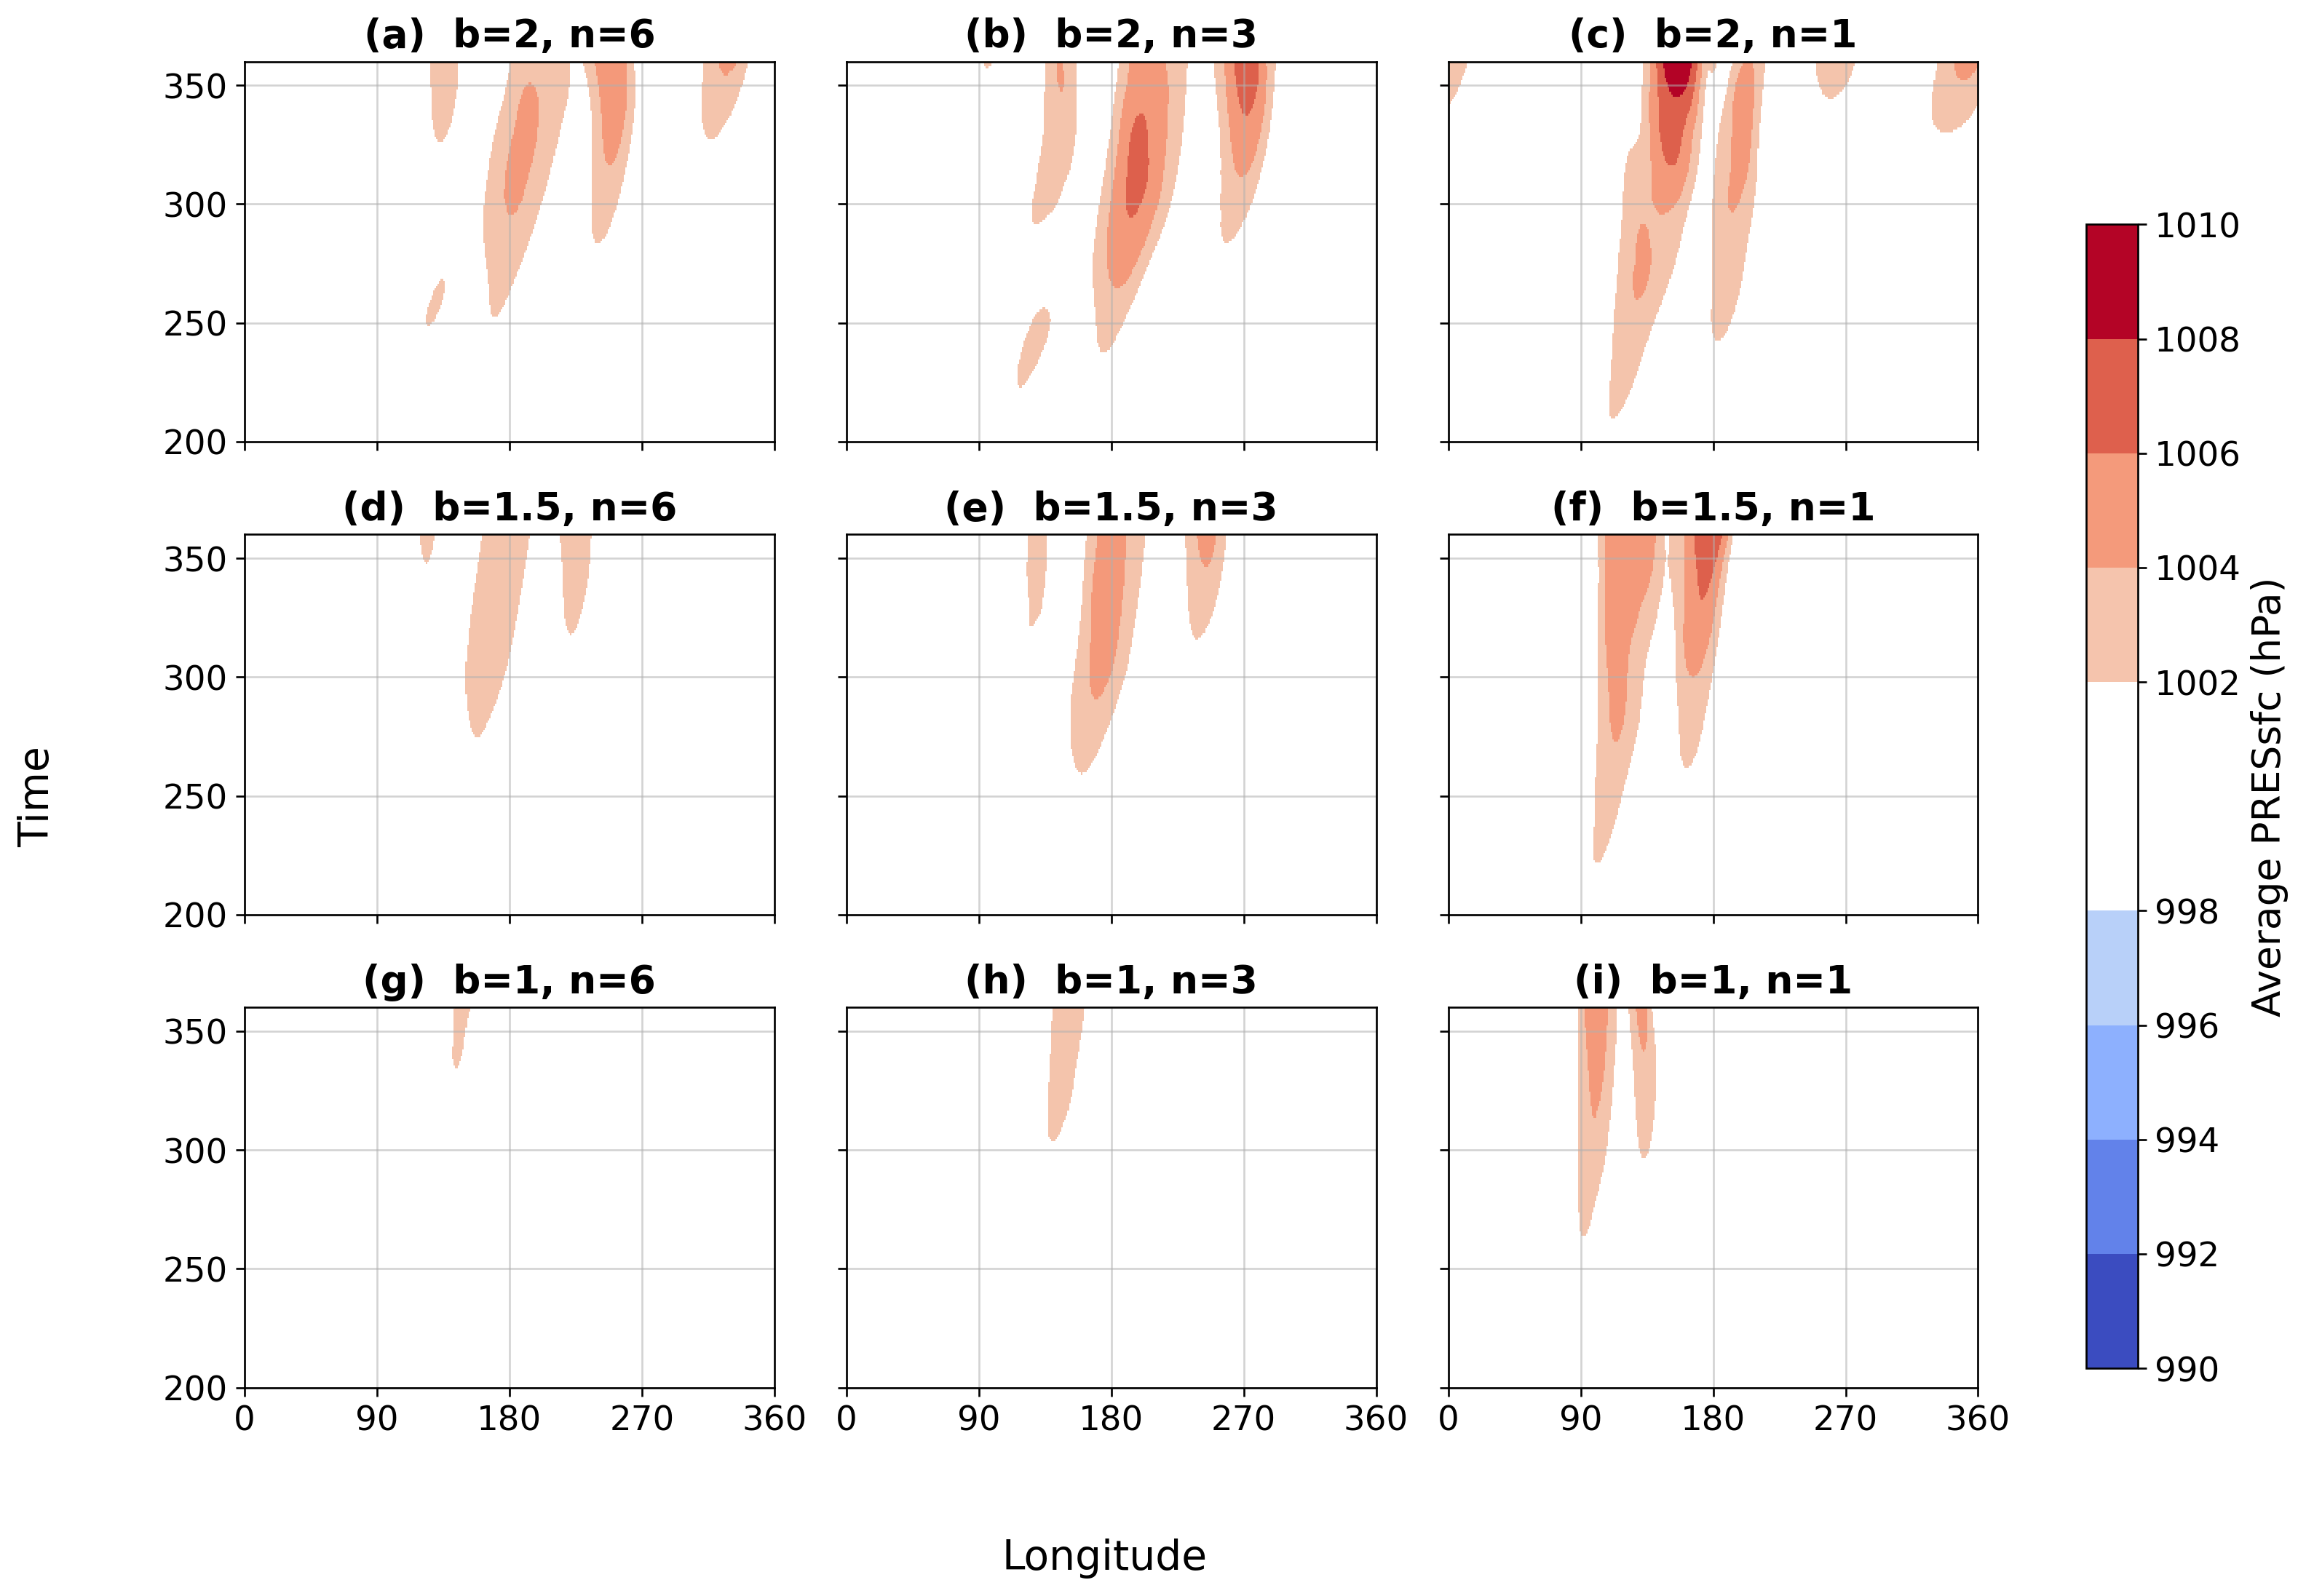

In [7]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            plot_figure12()
finally:
    sys.argv = _original_argv
show_files(['publication_notebooks/outputs/Figure12_high_pressure_hovmoller.png'])


## Figure 13


In [8]:
# -*- coding: utf-8 -*-
"""
translated note 5 translated notedifferent s translated note（2×3），translated noteas“ConTrack translated note=1 translated note stationary anticyclone translated note（hours）”：
- threshold: PRESsfc ≥ 1010 hPa (101000 Pa), gorl=">=", overlap=0.80, persistence=24h
- translated note flag==1 translated notetrack；iftranslated notefilefromtranslated note=1 translated note，translated noteas 0
- filetranslated note：
    s ≠ 0:  BCwave_b{b}n{n}s{s}.nc
    s = 0:  translated note BCwave_b{b}n{n}.nc，iftranslated noteexiststranslated notetry BCwave_b{b}n{n}s0.nc
- Plottingtranslated noteexample：2×3 translated note、LinearSegmentedColormap(white→red)、vmin=-200,vmax=200、NaN translated note、translated note
"""

import os
import warnings
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from contextlib import redirect_stdout, redirect_stderr

# ====== ConTrack ======
from contrack import contrack as ContrackClass

warnings.filterwarnings("ignore")

# ========== translated noteparameter ==========
folder = str(RAW_DIR)
n_levels = [6, 3, 1]          # translated notefrom 6,3,1
b_raw   = [2, 15, 1]          # raw b translated note（15 translated note 1.5）
b_levels = [1.0, 1.5, 2.0]    # translated note y translated note（translated notetotranslated note）
s_levels = [-10, -5, 0, 5, 10]

overlap = 0.80
persistence = 72             # hours
threshold_pa = 101000.0       # 1010 hPa
track_id_to_count = 1
# ============================

# ---------- translated note contrack ----------
class _Silent:
    def __enter__(self):
        self._devnull = open(os.devnull, "w")
        self._stdout = redirect_stdout(self._devnull)
        self._stderr = redirect_stderr(self._devnull)
        self._stdout.__enter__(); self._stderr.__enter__(); return self
    def __exit__(self, et, e, tb):
        self._stderr.__exit__(et, e, tb); self._stdout.__exit__(et, e, tb)
        self._devnull.close(); return False

# ---------- contrack timetranslated note（translated noteProcesstranslated note time translated note） ----------
def _get_resolution_patched(self, name, force=False):
    arr = np.asarray(self.ds[name].values)
    if arr.size < 2:
        return np.nan
    if np.issubdtype(arr.dtype, np.datetime64) or np.issubdtype(arr.dtype, np.timedelta64):
        dt_s = (arr[1] - arr[0]).astype("timedelta64[s]").astype("int64")
        return float(dt_s) / 3600.0
    return float(abs(arr[1] - arr[0]))
ContrackClass._get_resolution = _get_resolution_patched

# ---------- Readtranslated notecoordinate（translated note ConTrack translated note；translated note） ----------
def open_and_normalize(nc_path: str) -> xr.Dataset:
    ds = xr.open_dataset(nc_path, decode_times=False)

    # standardizedimensiontranslated note（ConTrack translated note latitude/longitude）
    if "grid_yt" in ds.dims: ds = ds.rename({"grid_yt": "latitude"})
    if "grid_xt" in ds.dims: ds = ds.rename({"grid_xt": "longitude"})

    # latitudeascending
    if "latitude" in ds.dims and ds["latitude"][0] > ds["latitude"][-1]:
        ds = ds.sortby("latitude")

    # longitudetranslated noteto [0,360)
    if "longitude" in ds:
        lon = (ds["longitude"].values % 360.0)
        ds = ds.assign_coords(longitude=("longitude", lon)).sortby("longitude")

    # standardizetimeas datetime64
    t = ds["time"]
    if   np.issubdtype(t.dtype, np.datetime64):
        pass
    elif np.issubdtype(t.dtype, np.timedelta64):
        base = np.datetime64("2000-01-01T00:00")
        ds = ds.assign_coords(time=base + t.astype("timedelta64[s]"))
    else:
        secs = np.rint(t.values.astype("float64") * 3600.0).astype("int64")
        base = np.datetime64("2000-01-01T00:00")
        ds = ds.assign_coords(time=base + secs.astype("timedelta64[s]"))
    return ds

# ---------- run ConTrack translated notereturn flag（time, lat, lon；translated noteas 0/1/2/...） ----------
def contrack_flag_high(nc_file, threshold_pa=101000.0, overlap=0.80, persistence=24):
    ds = open_and_normalize(nc_file)
    blk = ContrackClass(); blk.ds = ds.copy()
    with _Silent():
        blk.run_contrack(variable="PRESsfc",
                         threshold=float(threshold_pa),
                         gorl=">=",                  # high pressure：translated notethreshold
                         overlap=overlap,
                         persistence=persistence,
                         twosided=False)
    flag = blk.ds["flag"]
    if not np.issubdtype(flag.dtype, np.integer):
        flag = flag.fillna(0).astype(np.int32)
    return flag  # xr.DataArray(time, latitude, longitude)

# ---------- translated note“translated note=track_id translated notetrack”translated note（hours） ----------
def total_hours_for_track(flag3d: xr.DataArray, track_id: int = 1) -> float:
    tvals = flag3d["time"].values
    T = len(tvals)
    if T < 2:
        return 0.0

    # translated noteistranslated note“translated notetrackexists”
    active = np.array([bool(np.any(flag3d.isel(time=t).values == track_id)) for t in range(T)], dtype=bool)

    # adjacent Δt（hours）
    dt_hours = np.array([
        max( (tvals[t] - tvals[t-1]).astype("timedelta64[s]").astype("int64") / 3600.0, 1.0 )
        for t in range(1, T)
    ], dtype=float)

    # translated notecurrent timetranslated note
    return float(np.sum(dt_hours[active[1:]]))

# ---------- filetranslated noteparse/translated note（translated note s=0 translated note） ----------
def resolve_nc_path(folder: str, b: int, n: int, s: int) -> str | None:
    if s == 0:
        # translated note s translated note
        cand1 = os.path.join(folder, f"BCwave_b{b}n{n}.nc")
        if os.path.exists(cand1):
            return cand1
        cand2 = os.path.join(folder, f"BCwave_b{b}n{n}s0.nc")
        if os.path.exists(cand2):
            return cand2
        return None
    else:
        cand = os.path.join(folder, f"BCwave_b{b}n{n}s{s}.nc")
        return cand if os.path.exists(cand) else None

# ========= translated note：astranslated note s translated note (len(b_levels) × len(n_levels)) translated note =========
def compute_panel_for_s(s: int) -> np.ndarray:
    M = np.full((len(b_levels), len(n_levels)), np.nan, dtype=float)
    for j, b in enumerate(b_raw):     # translated noteraw b translated note，translated notemaptotranslated note
        # translated notemap：15 -> 1.5，translated note
        b_disp = 1.5 if b == 15 else float(b)
        r = b_levels.index(b_disp)    # intranslated notecentertranslated noterowindex
        for c, n in enumerate(n_levels):
            path = resolve_nc_path(folder, b, n, s)
            if path is None:
                print(f"⚠️ Missing file for s={s}: BCwave_b{b}n{n}[s{0 if s==0 else s}].nc")
                continue
            try:
                flag = contrack_flag_high(path, threshold_pa=threshold_pa, overlap=overlap, persistence=persistence)
                hours = total_hours_for_track(flag, track_id=track_id_to_count)
            except Exception as e:
                print(f"⚠️ Failed to process {os.path.basename(path)}: {e}")
                hours = 0.0
            M[r, c] = hours
    return M

# ========= Plotting（translated note，2×3 translated note，translated note） =========
def _scale_fontparams(factor=2.0):
    import matplotlib as mpl
    keys = ["font.size", "axes.labelsize", "axes.titlesize",
            "xtick.labelsize", "ytick.labelsize", "legend.fontsize"]
    for k in keys:
        val = mpl.rcParams[k]
        if isinstance(val, (int, float)):
            mpl.rcParams[k] = val * factor
        else:
            mpl.rcParams[k] = 14 * factor
    mpl.rcParams["lines.linewidth"] = 1.5 * factor

def plot_figure13():
    _scale_fontparams(2)

    # translated note s translated note
    panels = [compute_panel_for_s(s) for s in s_levels]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=150)
    axes = axes.ravel()
    labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

    # translated note，translated note；translated note -200..200
    cmap = LinearSegmentedColormap.from_list("red_only", ["white", "red"])
    cmap.set_bad(color="#e0e0e0")
    vmin, vmax = 0, 200

    for i, s in enumerate(s_levels):
        ax = axes[i]
        P = panels[i]

        im = ax.imshow(P, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")

        ax.set_xticks(np.arange(len(n_levels)))
        ax.set_xticklabels([str(n) for n in n_levels], ha="center")
        ax.set_yticks(np.arange(len(b_levels)))
        ax.set_yticklabels([str(b) for b in b_levels], va="center")

        ax.set_xlabel("n (wider jet →)")
        ax.set_ylabel("b (larger b →)")
        ax.set_title(f"{labels[i]}  s = {s}°", ha="center")

        # translated notecentertranslated note（keep 1 translated note）
        for r in range(len(b_levels)):
            for c in range(len(n_levels)):
                val = P[r, c]
                if np.isfinite(val):
                    ax.text(c, r, f"{val:.1f}", ha="center", va="center")

    # translated note
    axes[-1].axis("off")

    plt.tight_layout()
    return save_figure(fig, 'Figure13_anticyclone_overlap_duration.png')


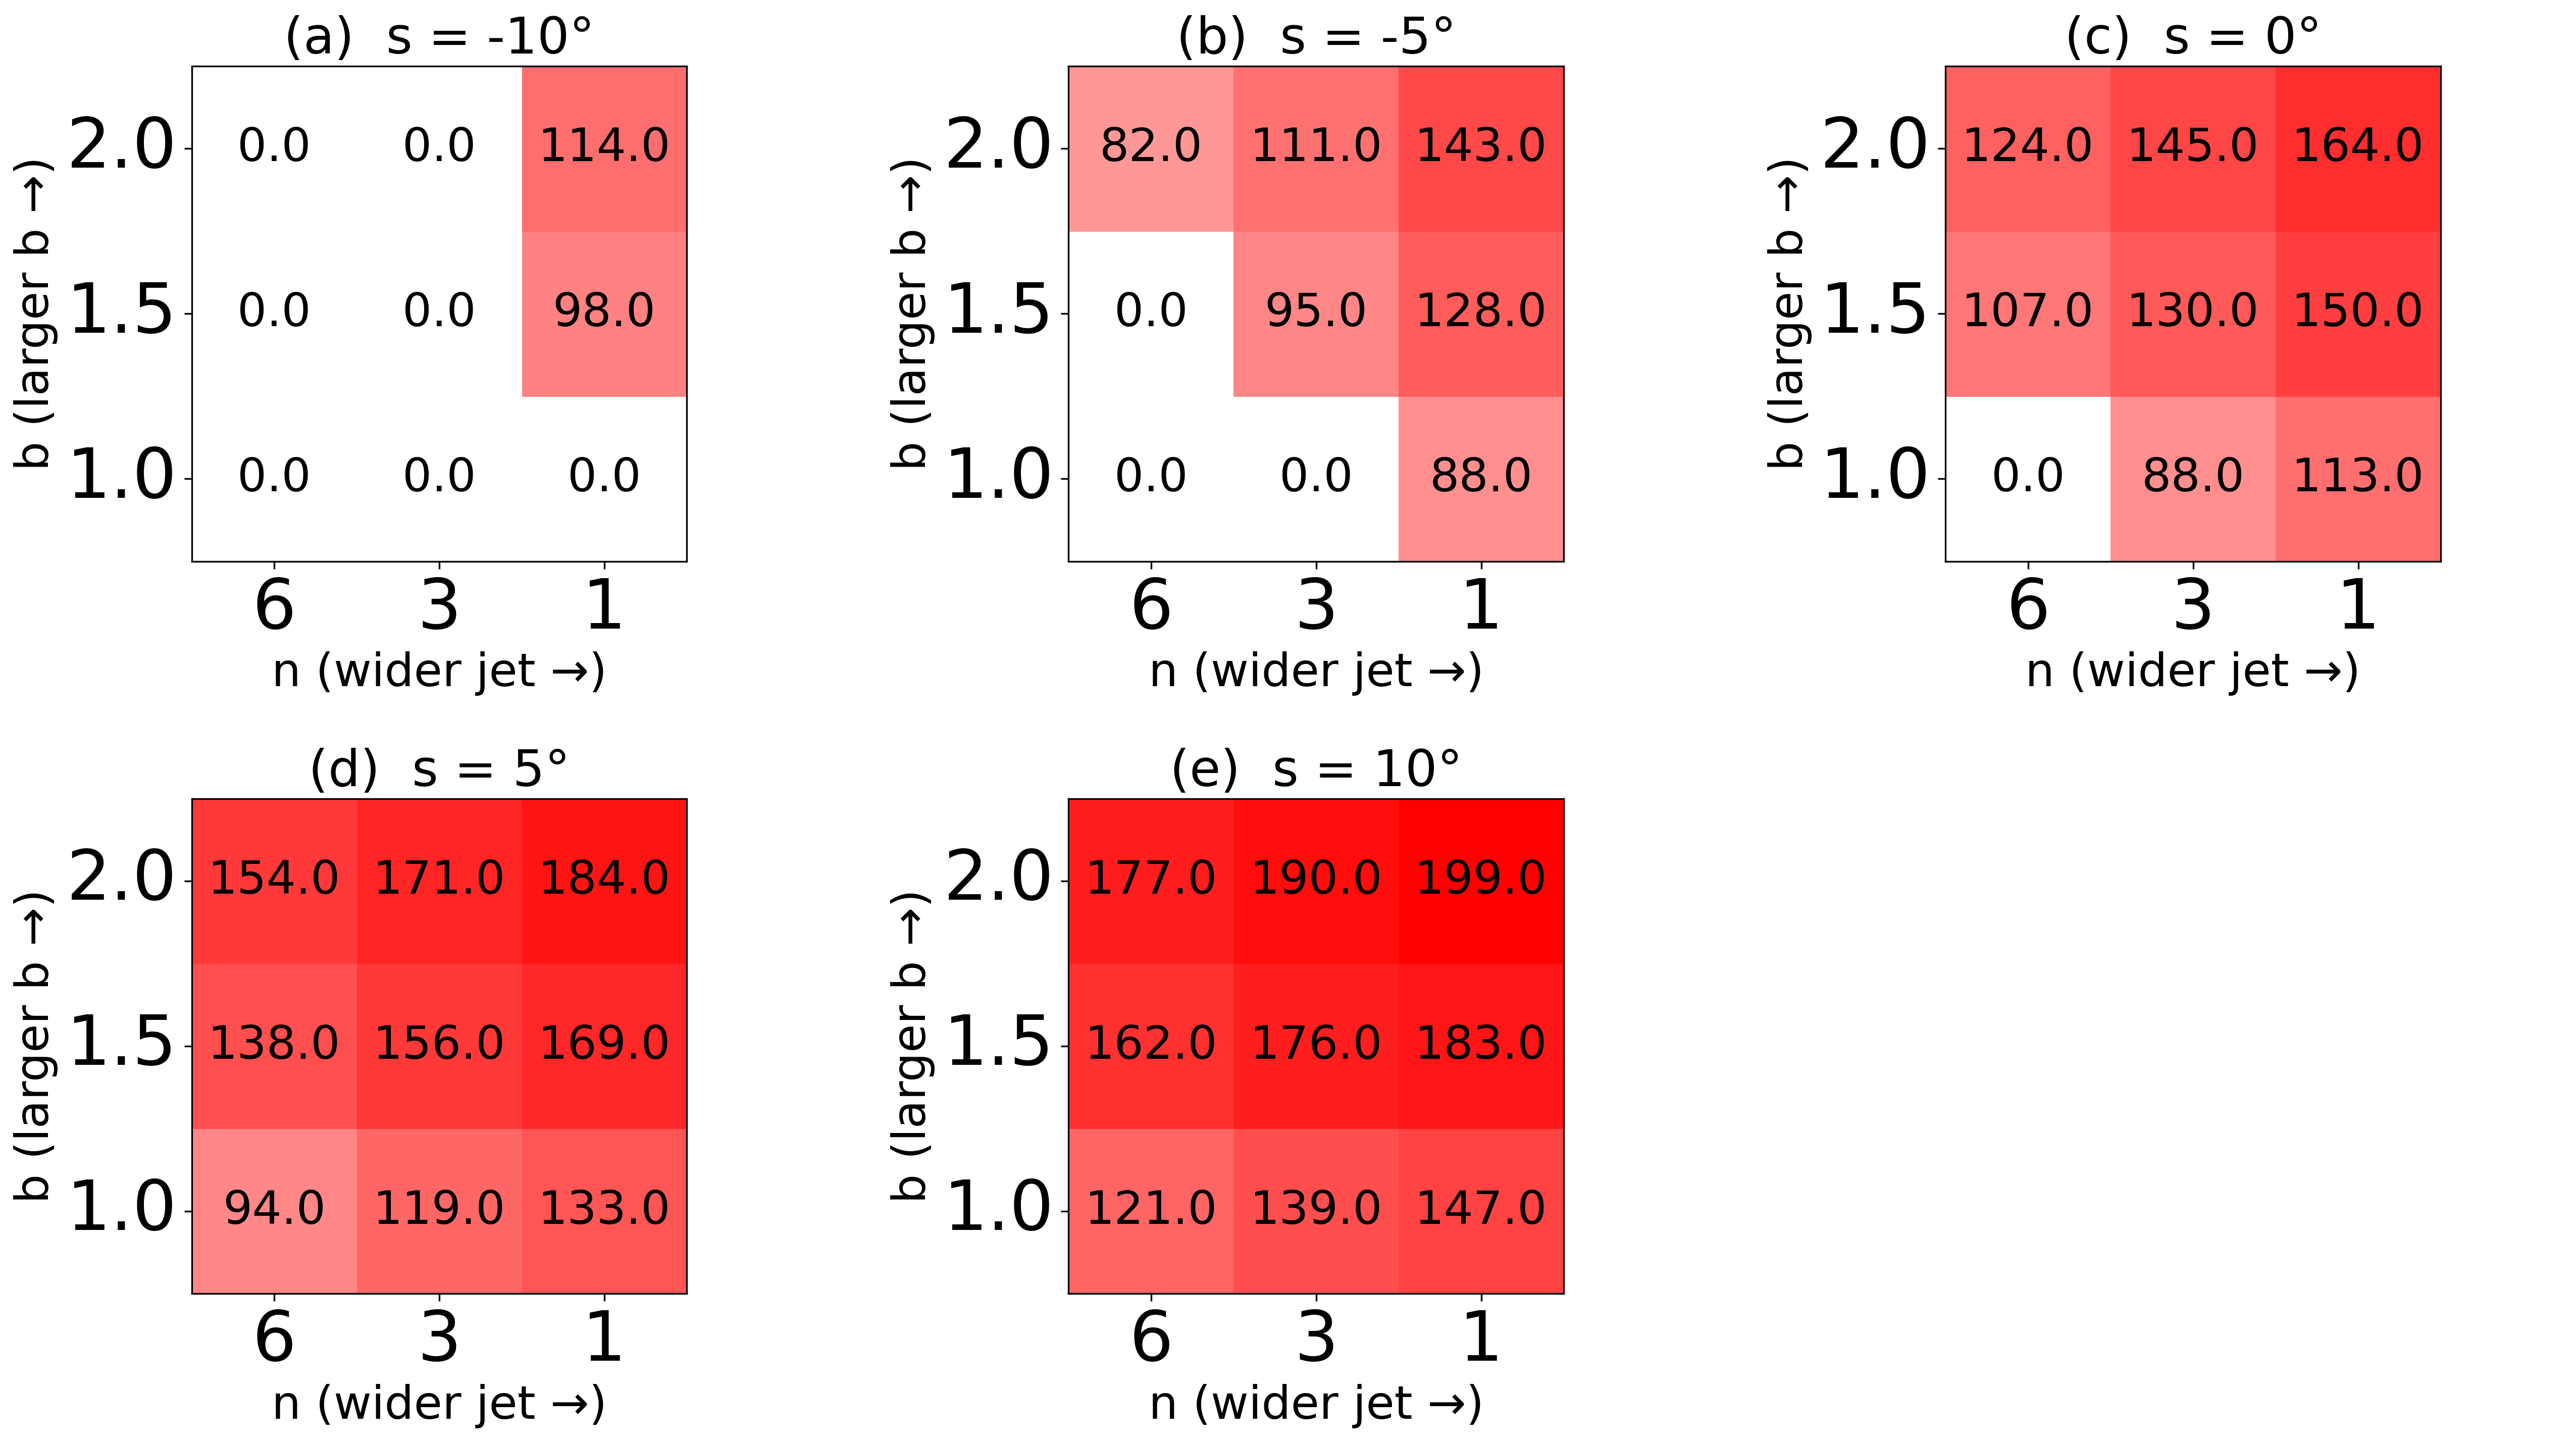

In [9]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            plot_figure13()
finally:
    sys.argv = _original_argv
show_files(['publication_notebooks/outputs/Figure13_anticyclone_overlap_duration.png'])
